# LeetCode #875: Koko Eating Bananas

https://leetcode.com/problems/koko-eating-bananas/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (try each speed 1..max)** | $O(n \times m)$ | $O(1)$ |
| **Optimal: Binary Search on Eating Speed ★** | $O(n \log m)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (try each speed 1..max)
For each candidate speed $k$ from 1 to max(piles), compute total hours and check if ≤ $h$. $O(n \times m)$ where $m = \max(\text{piles})$ — too slow for large inputs.

### Optimal: Binary Search on Eating Speed ★
Binary search on $k$ in the range $[1, \max(\text{piles})]$. For each candidate speed, compute total hours as $\sum \lceil \text{pile}_i / k \rceil$ in $O(n)$. If hours ≤ $h$, the speed is sufficient — try smaller (hi=mid); otherwise need faster (lo=mid+1). Converges to the minimum sufficient speed in $O(\log m)$ iterations.

**Constraints:**
* 1 <= piles.length <= 10^4
* piles.length <= h <= 10^9
* 1 <= piles[i] <= 10^9


## Solutions

### C#

In [ ]:
public int MinEatingSpeed(int[] piles, int h) {
    int lo = 1, hi = piles.Max();
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Calculate hours needed at speed mid
        long hours = piles.Sum(p => (long)(p + mid - 1) / mid);
        // If feasible, try a slower speed; else we need to go faster
        if (hours <= h) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
import math

def minEatingSpeed(self, piles: list[int], h: int) -> int:
    lo, hi = 1, max(piles)
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Calculate hours needed at speed mid
        hours = sum(math.ceil(p / mid) for p in piles)
        # If feasible, try a slower speed; else we need to go faster
        if hours <= h:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func minEatingSpeed(piles []int, h int) int {
    lo, hi := 1, 0
    for _, p := range piles { if p > hi { hi = p } }
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Calculate hours needed at speed mid
        hours := 0
        for _, p := range piles { hours += (p + mid - 1) / mid }
        // If feasible, try a slower speed; else we need to go faster
        if hours <= h { hi = mid } else { lo = mid + 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn min_eating_speed(piles: Vec<i32>, h: i32) -> i32 {
    let (mut lo, mut hi) = (1i32, *piles.iter().max().unwrap());
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Calculate hours needed at speed mid
        let hours: i64 = piles.iter().map(|&p| ((p + mid - 1) / mid) as i64).sum();
        // If feasible, try a slower speed; else we need to go faster
        if hours <= h as i64 { hi = mid; } else { lo = mid + 1; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** piles = [3, 6, 7, 11], h = 8
lo=1,hi=11. mid=6: hours=⌈3/6⌉+⌈6/6⌉+⌈7/6⌉+⌈11/6⌉=1+1+2+2=6≤8 → hi=6. mid=3: 1+2+3+4=10>8 → lo=4. mid=5: 1+2+2+3=8≤8 → hi=5. mid=4: 1+2+2+3=8≤8 → hi=4=lo → return 4.

**2. Slightly Complex**
**Input:** piles = [30, 11, 23, 4, 20], h = 5
h=5=len(piles) so Koko must eat each pile in exactly one hour → needs k≥max(piles)=30. Binary search converges to lo=30.

**3. Edge Case: Time Factor**
**Input:** piles = [10^9], h = 10^9
lo=1,hi=10^9. $\lceil \log_2(10^9) \rceil = 30$ iterations. At k=1: hours=10^9≤10^9 → valid. Converges to k=1. Note: hours computation uses long/int64 to avoid overflow when summing ceil values.

**4. Edge Case: Space Factor**
**Input:** piles = [1, 1, 1, ..., 1] (10^4 piles of 1), h = 10^4
hi=1. lo=hi=1 immediately (loop condition lo<hi=1 is false). Return 1. $O(1)$ extra space — only lo, hi, mid, hours (all scalars).

**5. Almost-Impossible but Plausible**
**Input:** piles = [10^9, 10^9, ..., 10^9] (10^4 piles), h = 10^9
Need $\sum \lceil 10^9/k \rceil \leq 10^9$. At k=10^4: hours=10^4 × ⌈10^9/10^4⌉=10^4×10^5=10^9≤h → valid. Binary search in [1,10^9] converges to k=10^4 in 30 steps. Critical: int overflow if hours accumulated in int32 — must use int64 ($10^4 \times 10^9 = 10^{13}$).


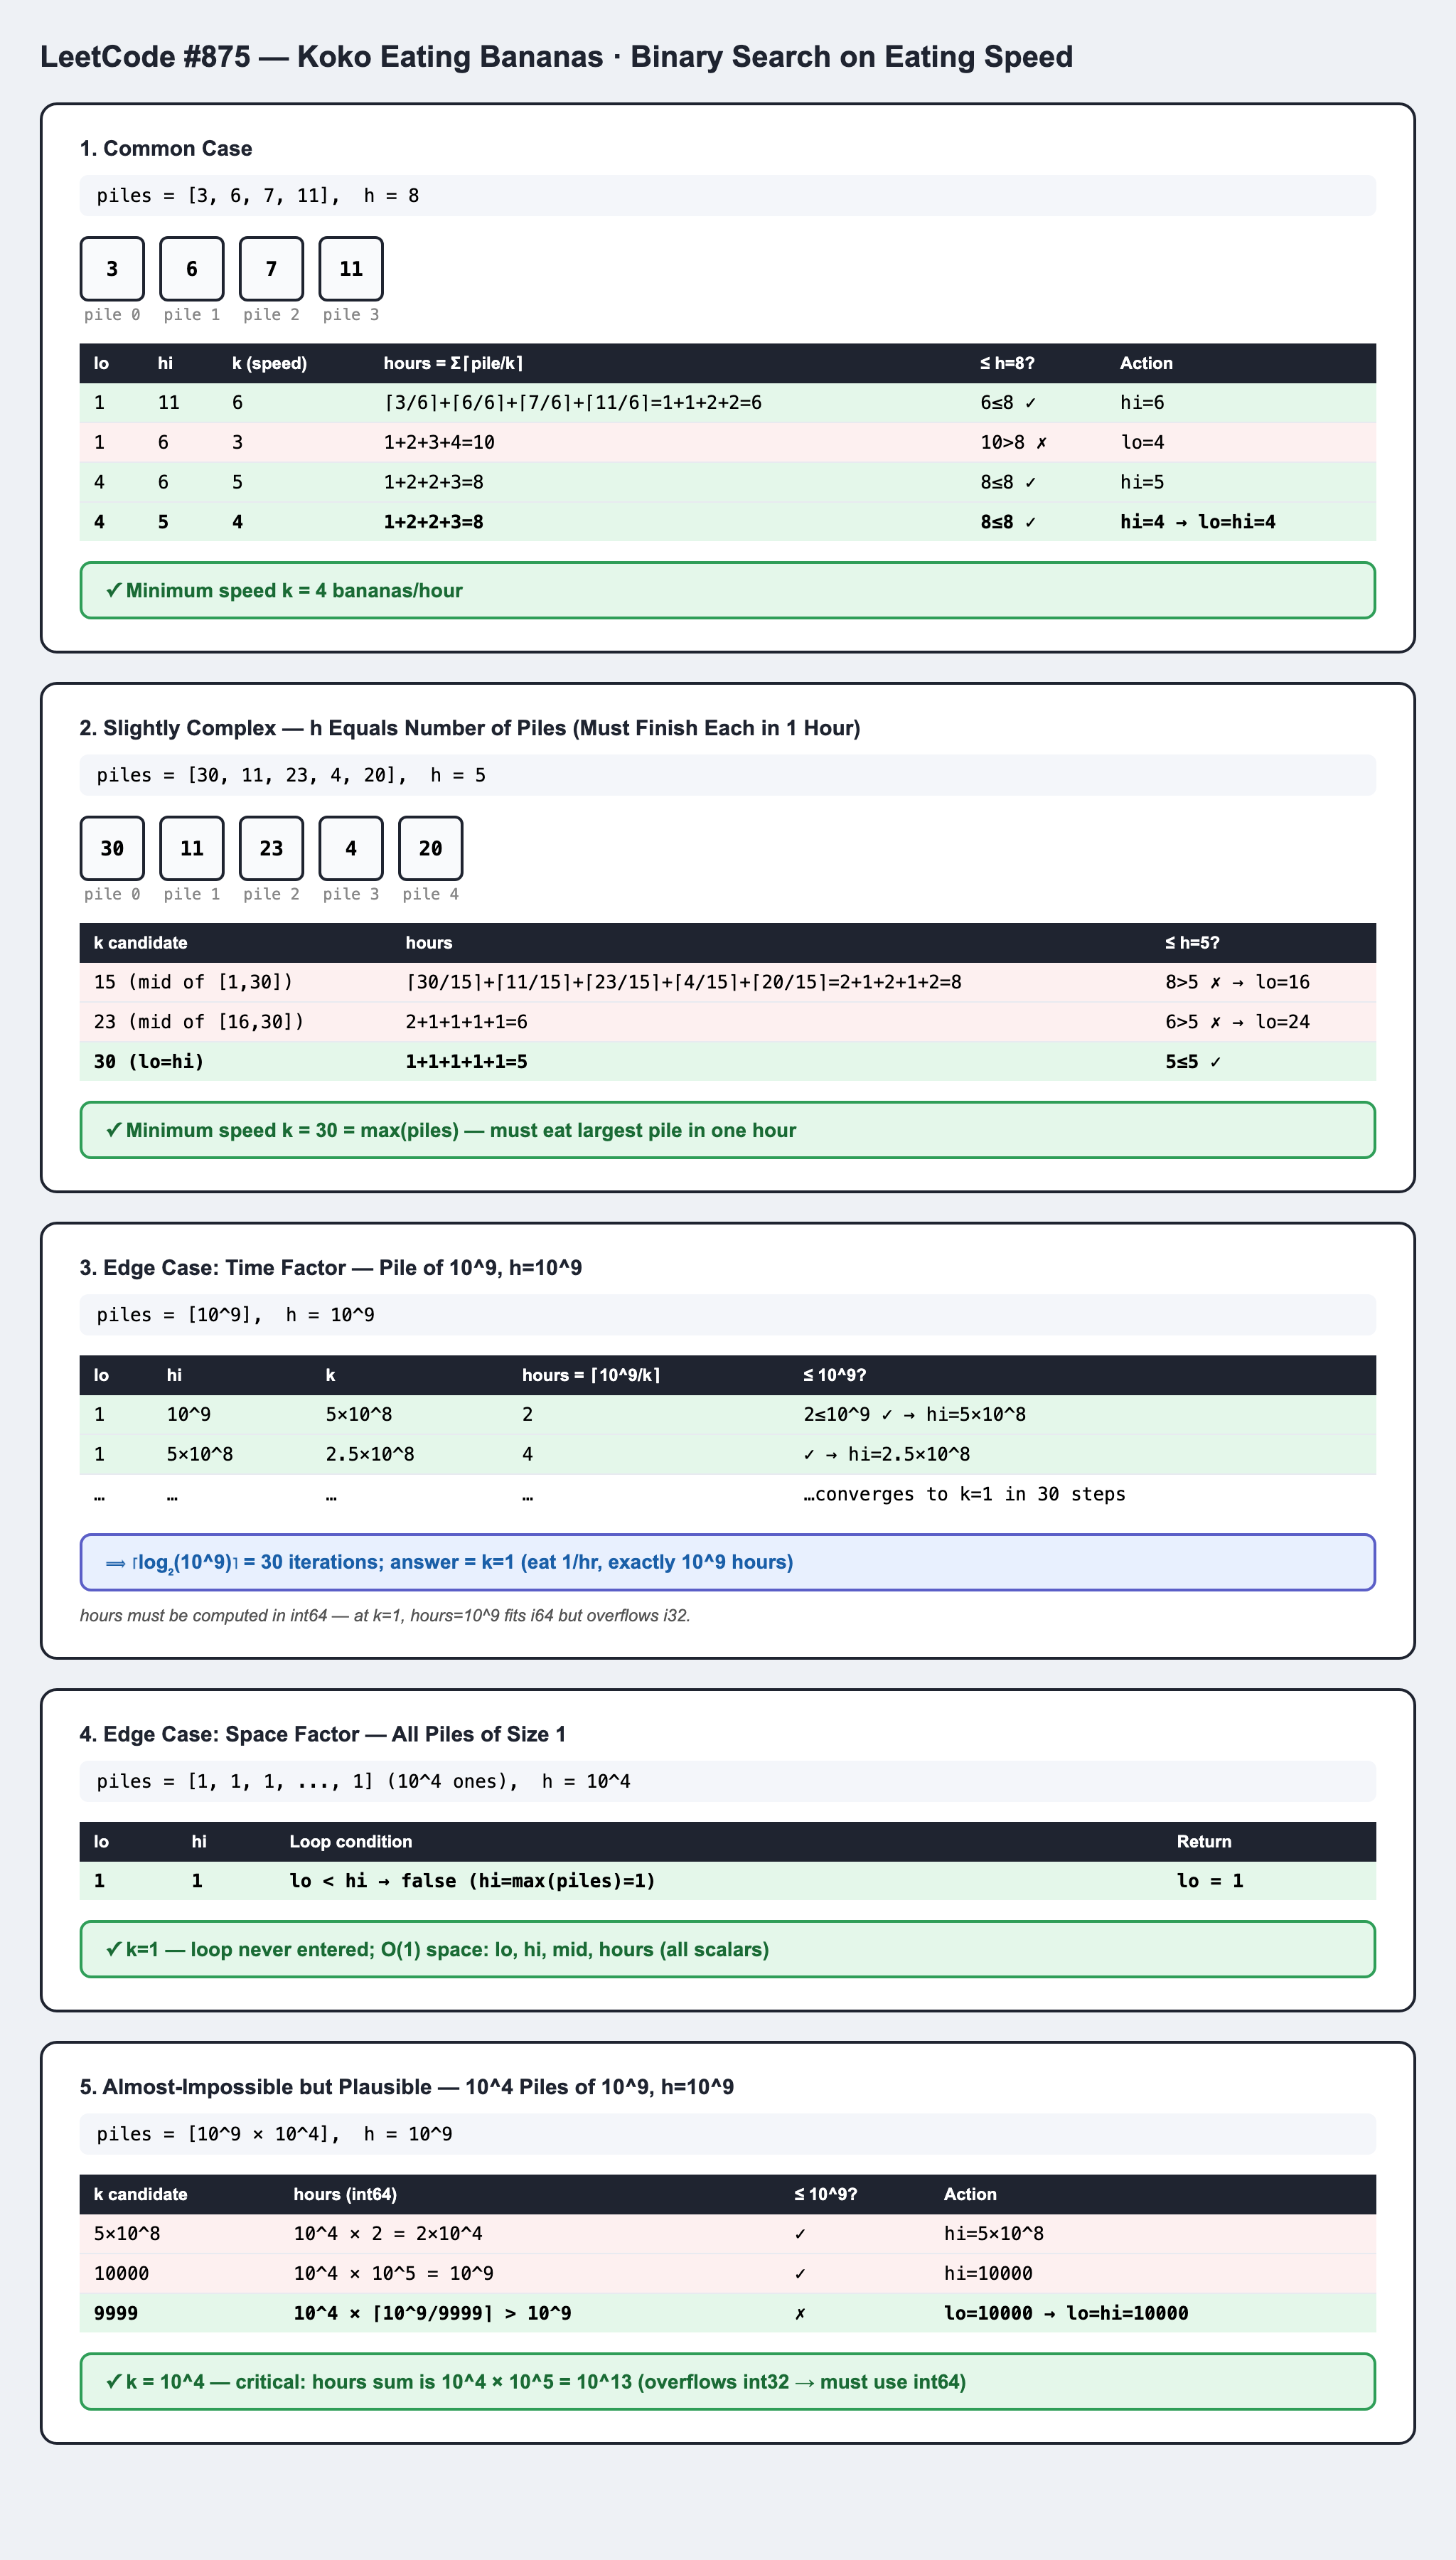